In [79]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gkalpolukcu/knn-algorithm-dataset/KNNAlgorithmDataset.csv


In [80]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/gkalpolukcu/knn-algorithm-dataset/KNNAlgorithmDataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [81]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 569
Number of Columns: 33


In [82]:
print("Column Names and Data Types:")
print(df.dtypes)


Column Names and Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst         

In [83]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

In [84]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [85]:
df = df.drop(columns=["Unnamed: 32"])

print("Column removed successfully!")
print("New Shape:", df.shape)

Column removed successfully!
New Shape: (569, 32)


In [86]:
print("Total IDs:", df["id"].count())
print("Unique IDs:", df["id"].nunique())

Total IDs: 569
Unique IDs: 569


In [87]:
print("Diagnosis Class Distribution:")
print(df["diagnosis"].value_counts())

Diagnosis Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [88]:
class_percentage = df["diagnosis"].value_counts(normalize=True) * 100

print("Diagnosis Class Percentage:")
print(class_percentage)

Diagnosis Class Percentage:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [89]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


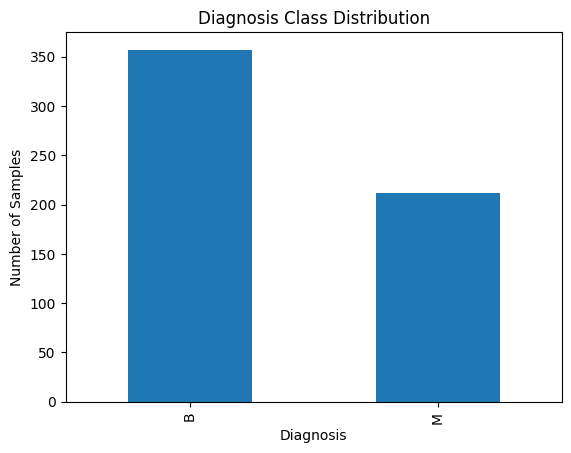

In [90]:
import matplotlib.pyplot as plt

df["diagnosis"].value_counts().plot(kind="bar")

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

In [91]:
correlation = df.drop(columns=["id"]).corr(numeric_only=True)

print("Correlation matrix created successfully!")
correlation.head()

Correlation matrix created successfully!


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


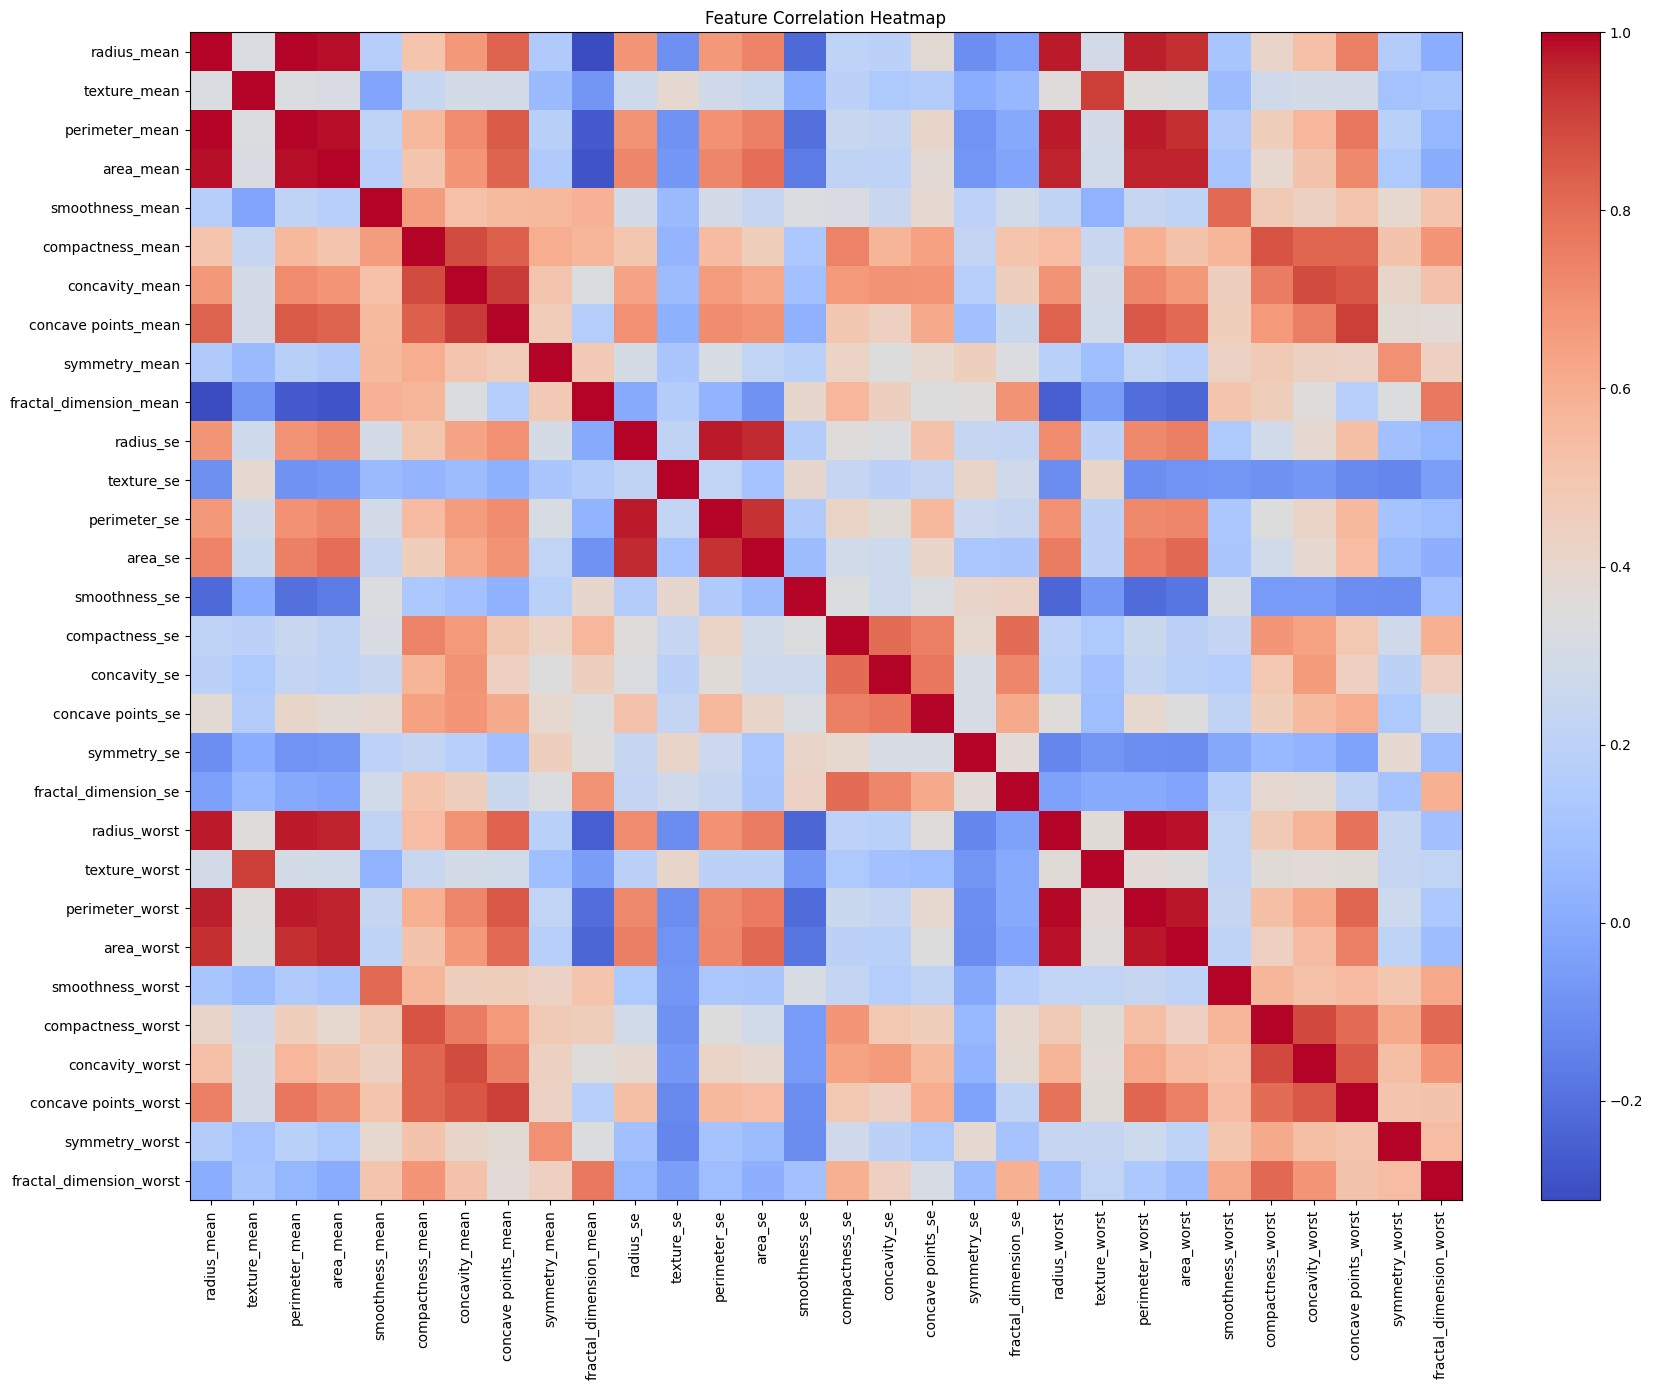

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [93]:
X = df.drop(columns=["diagnosis", "id"])
y = df["diagnosis"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features (X) shape: (569, 30)
Target (y) shape: (569,)

Target values:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully!
X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


In [96]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN model training completed successfully!")

KNN model training completed successfully!


In [97]:
y_pred = knn.predict(X_test_scaled)

print("Predictions completed successfully!")
print("Number of Predictions:", len(y_pred))
print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions completed successfully!
Number of Predictions: 114

First 10 Predictions:
['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B']


In [98]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("KNN Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

KNN Model Accuracy: 0.956140350877193
Accuracy Percentage: 95.6140350877193 %


In [99]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[71  1]
 [ 4 38]]


In [100]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [101]:
k_values = [1, 3, 5, 7, 9]
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    
    k_accuracies.append(accuracy)

    print(f"K = {k}, Accuracy = {accuracy:.4f}, Percentage = {accuracy * 100:.2f}%")

K = 1, Accuracy = 0.9298, Percentage = 92.98%
K = 3, Accuracy = 0.9386, Percentage = 93.86%
K = 5, Accuracy = 0.9561, Percentage = 95.61%
K = 7, Accuracy = 0.9561, Percentage = 95.61%
K = 9, Accuracy = 0.9474, Percentage = 94.74%


In [102]:
k_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": k_accuracies
})

k_results["Accuracy Percentage"] = k_results["Accuracy"] * 100

print("KNN K-value results:")
print(k_results)

KNN K-value results:
   K  Accuracy  Accuracy Percentage
0  1  0.929825            92.982456
1  3  0.938596            93.859649
2  5  0.956140            95.614035
3  7  0.956140            95.614035
4  9  0.947368            94.736842


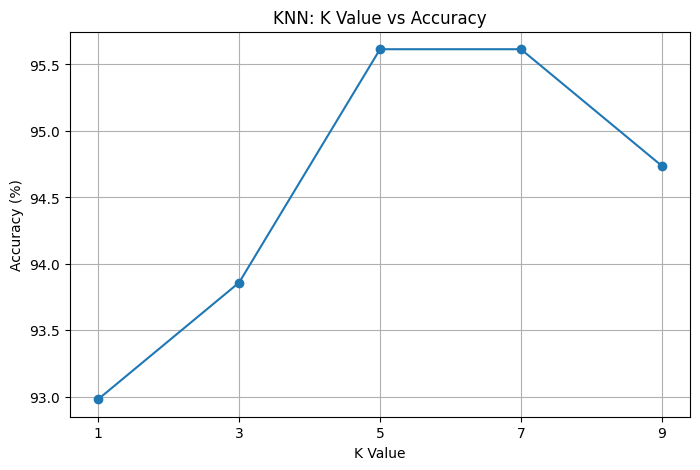

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(k_results["K"], k_results["Accuracy Percentage"], marker="o")

plt.title("KNN: K Value vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [104]:
final_knn = KNeighborsClassifier(n_neighbors=5)

final_knn.fit(X_train_scaled, y_train)

print("Final KNN model training completed successfully!")
print("Final K value:", final_knn.n_neighbors)

Final KNN model training completed successfully!
Final K value: 5


In [105]:
final_y_pred = final_knn.predict(X_test_scaled)

print("Final predictions completed successfully!")
print("Number of predictions:", len(final_y_pred))

print("\nFirst 10 final predictions:")
print(final_y_pred[:10])

Final predictions completed successfully!
Number of predictions: 114

First 10 final predictions:
['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B']


In [106]:
final_accuracy = accuracy_score(y_test, final_y_pred)

print("Final KNN Model Accuracy:", final_accuracy)
print("Final Accuracy Percentage:", final_accuracy * 100, "%")

Final KNN Model Accuracy: 0.956140350877193
Final Accuracy Percentage: 95.6140350877193 %


In [107]:
final_cm = confusion_matrix(y_test, final_y_pred)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[71  1]
 [ 4 38]]


In [108]:
final_report = classification_report(y_test, final_y_pred)

print("Final KNN Classification Report:")
print(final_report)

Final KNN Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [109]:
comparison = pd.DataFrame({
    "Actual Diagnosis": y_test.values,
    "Predicted Diagnosis": final_y_pred
})

print("Actual vs Predicted:")
print(comparison.head(15))

Actual vs Predicted:
   Actual Diagnosis Predicted Diagnosis
0                 B                   B
1                 M                   M
2                 B                   B
3                 M                   B
4                 B                   B
5                 B                   B
6                 M                   M
7                 B                   B
8                 B                   B
9                 B                   B
10                M                   M
11                B                   B
12                M                   M
13                B                   B
14                B                   B


In [110]:
errors = comparison[comparison["Actual Diagnosis"] != comparison["Predicted Diagnosis"]]

print("Incorrect Predictions:")
print(errors)

print("\nTotal Incorrect Predictions:", len(errors))

Incorrect Predictions:
    Actual Diagnosis Predicted Diagnosis
3                  M                   B
16                 M                   B
18                 B                   M
42                 M                   B
112                M                   B

Total Incorrect Predictions: 5


In [111]:
error_positions = errors.index

error_samples = X_test.iloc[error_positions].copy()

error_samples["Actual Diagnosis"] = errors["Actual Diagnosis"].values
error_samples["Predicted Diagnosis"] = errors["Predicted Diagnosis"].values

print("Incorrectly Classified Samples:")
print(error_samples)

Incorrectly Classified Samples:
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
99         14.42         19.77           94.48      642.5          0.09752   
73         13.80         15.79           90.43      584.1          0.10070   
208        13.11         22.54           87.02      529.4          0.10020   
385        14.60         23.29           93.97      664.7          0.08682   
205        15.12         16.68           98.78      716.6          0.08876   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
99            0.11410         0.09388              0.05839         0.1879   
73            0.12800         0.07789              0.05069         0.1662   
208           0.14830         0.08705              0.05102         0.1850   
385           0.06636         0.08390              0.05271         0.1627   
205           0.09588         0.07550              0.04079         0.1594   

     fractal_dimension_mean  ...  pe

In [112]:
error_types = errors.copy()

error_types["Error Type"] = error_types.apply(
    lambda row: "False Negative (M → B)"
    if row["Actual Diagnosis"] == "M" and row["Predicted Diagnosis"] == "B"
    else "False Positive (B → M)",
    axis=1
)

print("Error Type Analysis:")
print(error_types)

Error Type Analysis:
    Actual Diagnosis Predicted Diagnosis              Error Type
3                  M                   B  False Negative (M → B)
16                 M                   B  False Negative (M → B)
18                 B                   M  False Positive (B → M)
42                 M                   B  False Negative (M → B)
112                M                   B  False Negative (M → B)


Error Counts:
Error Type
False Negative (M → B)    4
False Positive (B → M)    1
Name: count, dtype: int64


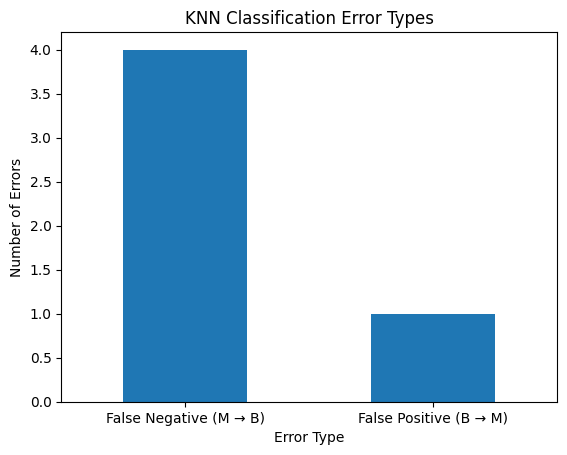

In [113]:
error_counts = error_types["Error Type"].value_counts()

print("Error Counts:")
print(error_counts)

error_counts.plot(kind="bar")

plt.title("KNN Classification Error Types")
plt.xlabel("Error Type")
plt.ylabel("Number of Errors")
plt.xticks(rotation=0)

plt.show()

In [114]:
y_proba = final_knn.predict_proba(X_test_scaled)[:, 1]

print("Probability predictions generated successfully!")
print("Number of probability predictions:", len(y_proba))
print("\nFirst 10 probability predictions:")
print(y_proba[:10])

Probability predictions generated successfully!
Number of probability predictions: 114

First 10 probability predictions:
[0.  1.  0.  0.2 0.  0.  0.8 0.  0.  0. ]


In [115]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    (y_test == "M").astype(int),
    y_proba
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.982308201058201


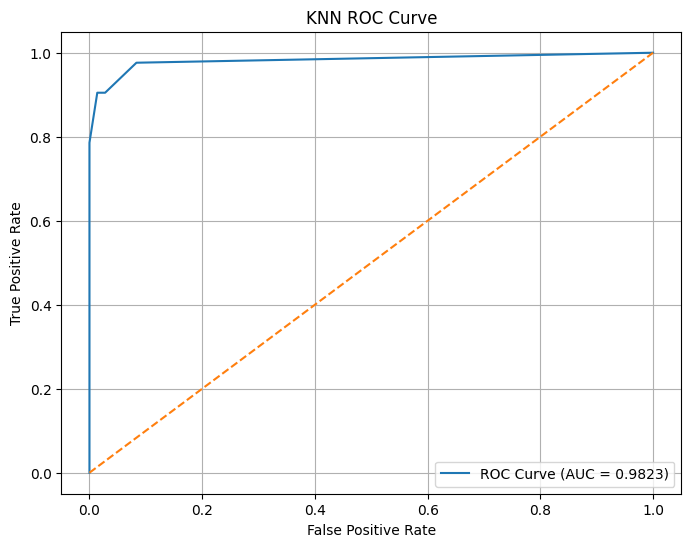

In [116]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_test_binary = (y_test == "M").astype(int)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(y_test, final_y_pred)

final_precision = precision_score(
    y_test,
    final_y_pred,
    pos_label="M"
)

final_recall = recall_score(
    y_test,
    final_y_pred,
    pos_label="M"
)

final_f1 = f1_score(
    y_test,
    final_y_pred,
    pos_label="M"
)

performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (M)",
        "Recall (M)",
        "F1-Score (M)",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        roc_auc
    ]
})

performance_summary["Percentage"] = performance_summary["Score"] * 100

print("Final KNN Performance Summary:")
print(performance_summary)

Final KNN Performance Summary:
          Metric     Score  Percentage
0       Accuracy  0.956140   95.614035
1  Precision (M)  0.974359   97.435897
2     Recall (M)  0.904762   90.476190
3   F1-Score (M)  0.938272   93.827160
4        ROC-AUC  0.982308   98.230820


In [118]:
from sklearn.model_selection import cross_val_score

cv_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append({
        "K": k,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

print("Cross-Validation Results:")
print(cv_results)

Cross-Validation Results:
   K  Mean CV Accuracy  Std CV Accuracy
0  1          0.947253         0.014579
1  3          0.969231         0.021308
2  5          0.962637         0.023671
3  7          0.969231         0.023466
4  9          0.964835         0.018906


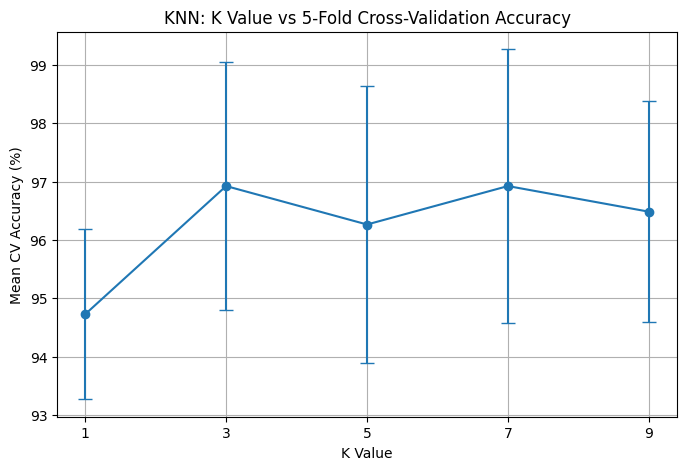

In [119]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    cv_results["K"],
    cv_results["Mean CV Accuracy"] * 100,
    yerr=cv_results["Std CV Accuracy"] * 100,
    marker="o",
    capsize=5
)

plt.title("KNN: K Value vs 5-Fold Cross-Validation Accuracy")
plt.xlabel("K Value")
plt.ylabel("Mean CV Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [120]:
best_k = cv_results.loc[
    cv_results["Mean CV Accuracy"].idxmax(),
    "K"
]

print("Selected K based on 5-Fold Cross-Validation:", best_k)

Selected K based on 5-Fold Cross-Validation: 3


In [121]:
final_knn_cv = KNeighborsClassifier(n_neighbors=best_k)

final_knn_cv.fit(X_train_scaled, y_train)

print("Final KNN model trained successfully!")
print("Selected K:", final_knn_cv.n_neighbors)

Final KNN model trained successfully!
Selected K: 3


In [122]:
final_cv_y_pred = final_knn_cv.predict(X_test_scaled)

print("Final test predictions completed successfully!")
print("Number of predictions:", len(final_cv_y_pred))

print("\nFirst 10 predictions:")
print(final_cv_y_pred[:10])

Final test predictions completed successfully!
Number of predictions: 114

First 10 predictions:
['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B']


In [123]:
final_cv_accuracy = accuracy_score(y_test, final_cv_y_pred)

print("Final KNN Accuracy:", final_cv_accuracy)
print("Final KNN Accuracy Percentage:", final_cv_accuracy * 100, "%")

Final KNN Accuracy: 0.9385964912280702
Final KNN Accuracy Percentage: 93.85964912280701 %


In [124]:
final_cv_cm = confusion_matrix(y_test, final_cv_y_pred)

print("Final KNN Confusion Matrix:")
print(final_cv_cm)

Final KNN Confusion Matrix:
[[71  1]
 [ 6 36]]


In [125]:
final_cv_report = classification_report(
    y_test,
    final_cv_y_pred
)

print("Final KNN Classification Report:")
print(final_cv_report)

Final KNN Classification Report:
              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [126]:
final_cv_y_proba = final_knn_cv.predict_proba(X_test_scaled)[:, 1]

final_cv_roc_auc = roc_auc_score(
    (y_test == "M").astype(int),
    final_cv_y_proba
)

print("Final KNN ROC-AUC:", final_cv_roc_auc)
print("Final KNN ROC-AUC Percentage:", final_cv_roc_auc * 100, "%")

Final KNN ROC-AUC: 0.982473544973545
Final KNN ROC-AUC Percentage: 98.2473544973545 %


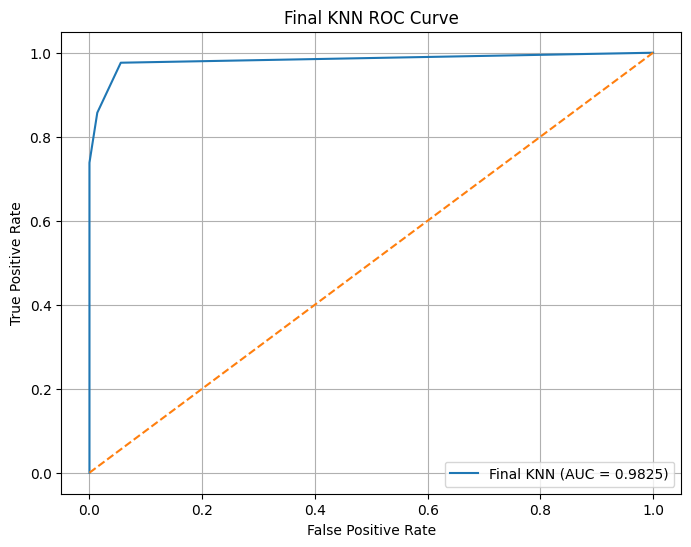

In [127]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

final_fpr, final_tpr, final_thresholds = roc_curve(
    (y_test == "M").astype(int),
    final_cv_y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    final_fpr,
    final_tpr,
    label=f"Final KNN (AUC = {final_cv_roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Final KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [128]:
from sklearn.metrics import precision_score, recall_score, f1_score

final_precision = precision_score(
    y_test,
    final_cv_y_pred,
    pos_label="M"
)

final_recall = recall_score(
    y_test,
    final_cv_y_pred,
    pos_label="M"
)

final_f1 = f1_score(
    y_test,
    final_cv_y_pred,
    pos_label="M"
)

final_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (M)",
        "Recall (M)",
        "F1-Score (M)",
        "ROC-AUC"
    ],
    "Score": [
        final_cv_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_cv_roc_auc
    ]
})

final_performance["Percentage"] = final_performance["Score"] * 100

print("Final KNN Performance Summary:")
print(final_performance)

Final KNN Performance Summary:
          Metric     Score  Percentage
0       Accuracy  0.938596   93.859649
1  Precision (M)  0.972973   97.297297
2     Recall (M)  0.857143   85.714286
3   F1-Score (M)  0.911392   91.139241
4        ROC-AUC  0.982474   98.247354


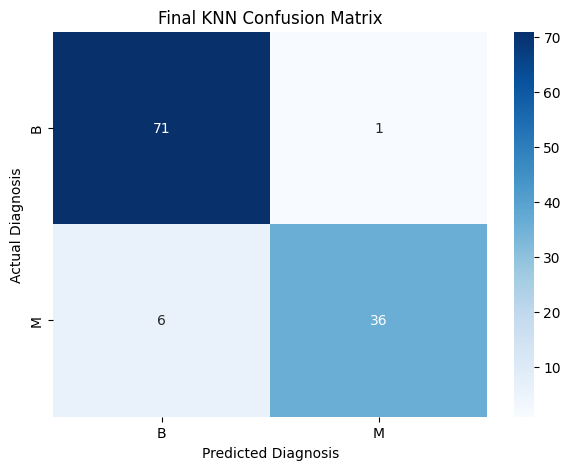

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cv_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["B", "M"],
    yticklabels=["B", "M"]
)

plt.title("Final KNN Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

pipeline_cv_results = []

for k in k_values:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    pipeline_cv_results.append({
        "K": k,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

pipeline_cv_results = pd.DataFrame(pipeline_cv_results)

print("Professional 5-Fold Cross-Validation Results:")
print(pipeline_cv_results)

Professional 5-Fold Cross-Validation Results:
   K  Mean CV Accuracy  Std CV Accuracy
0  1          0.947253         0.014579
1  3          0.967033         0.020850
2  5          0.962637         0.022628
3  7          0.969231         0.023466
4  9          0.967033         0.015541


In [131]:
best_k = pipeline_cv_results.loc[
    pipeline_cv_results["Mean CV Accuracy"].idxmax(),
    "K"
]

best_cv_accuracy = pipeline_cv_results.loc[
    pipeline_cv_results["Mean CV Accuracy"].idxmax(),
    "Mean CV Accuracy"
]

print("Final K selected using 5-Fold Cross-Validation:", best_k)
print("Mean CV Accuracy:", best_cv_accuracy)
print("Mean CV Accuracy Percentage:", best_cv_accuracy * 100, "%")

Final K selected using 5-Fold Cross-Validation: 7
Mean CV Accuracy: 0.9692307692307693
Mean CV Accuracy Percentage: 96.92307692307693 %


In [132]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train, y_train)

print("Final Professional KNN Model trained successfully!")
print("Selected K:", best_k)

Final Professional KNN Model trained successfully!
Selected K: 7


In [133]:
final_predictions = final_model.predict(X_test)

print("Final test predictions completed successfully!")
print("Number of predictions:", len(final_predictions))

print("\nFirst 10 Predictions:")
print(final_predictions[:10])

Final test predictions completed successfully!
Number of predictions: 114

First 10 Predictions:
['B' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B']


In [134]:
from sklearn.metrics import accuracy_score

final_test_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Final Test Accuracy:", final_test_accuracy)
print("Final Test Accuracy Percentage:", final_test_accuracy * 100, "%")

Final Test Accuracy: 0.956140350877193
Final Test Accuracy Percentage: 95.6140350877193 %


Final KNN Confusion Matrix:
[[71  1]
 [ 4 38]]


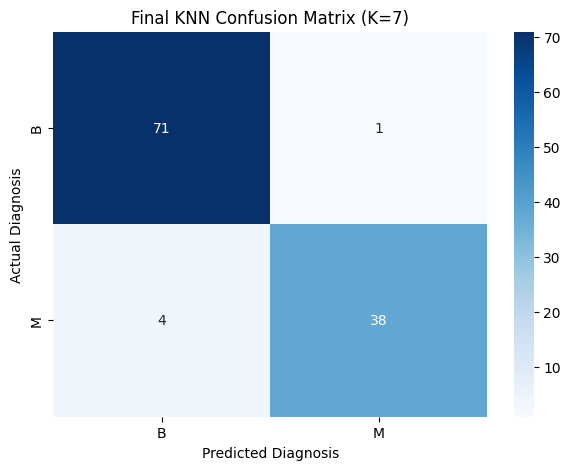

In [135]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

final_cm = confusion_matrix(y_test, final_predictions)

print("Final KNN Confusion Matrix:")
print(final_cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["B", "M"],
    yticklabels=["B", "M"]
)

plt.title("Final KNN Confusion Matrix (K=7)")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [136]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_precision = precision_score(
    y_test,
    final_predictions,
    pos_label="M"
)

final_recall = recall_score(
    y_test,
    final_predictions,
    pos_label="M"
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    pos_label="M"
)

final_probabilities = final_model.predict_proba(X_test)[:, 1]

final_roc_auc = roc_auc_score(
    (y_test == "M").astype(int),
    final_probabilities
)

print("Final KNN Performance Metrics (K=7)")
print("-----------------------------------")
print("Accuracy:", final_test_accuracy)
print("Precision (M):", final_precision)
print("Recall (M):", final_recall)
print("F1-Score (M):", final_f1)
print("ROC-AUC:", final_roc_auc)

Final KNN Performance Metrics (K=7)
-----------------------------------
Accuracy: 0.956140350877193
Precision (M): 0.9743589743589743
Recall (M): 0.9047619047619048
F1-Score (M): 0.9382716049382716
ROC-AUC: 0.982473544973545


In [137]:
from sklearn.metrics import classification_report

final_report = classification_report(
    y_test,
    final_predictions,
    target_names=["Benign (B)", "Malignant (M)"]
)

print("Final KNN Classification Report (K=7)")
print("--------------------------------------")
print(final_report)

Final KNN Classification Report (K=7)
--------------------------------------
               precision    recall  f1-score   support

   Benign (B)       0.95      0.99      0.97        72
Malignant (M)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



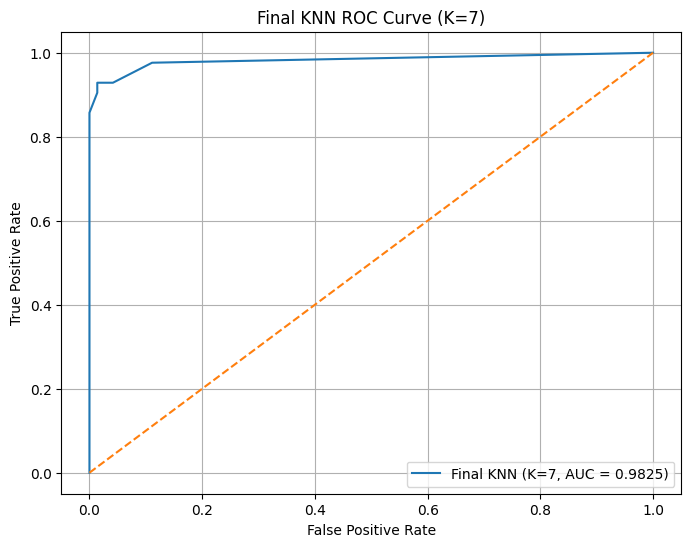

In [138]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

final_fpr, final_tpr, final_thresholds = roc_curve(
    (y_test == "M").astype(int),
    final_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    final_fpr,
    final_tpr,
    label=f"Final KNN (K=7, AUC = {final_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Final KNN ROC Curve (K=7)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [139]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (M)",
        "Recall (M)",
        "F1-Score (M)",
        "ROC-AUC"
    ],
    "Score": [
        final_test_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_summary["Percentage"] = final_summary["Score"] * 100

print("Final KNN Model Performance Summary")
print("------------------------------------")
print(final_summary)

Final KNN Model Performance Summary
------------------------------------
          Metric     Score  Percentage
0       Accuracy  0.956140   95.614035
1  Precision (M)  0.974359   97.435897
2     Recall (M)  0.904762   90.476190
3   F1-Score (M)  0.938272   93.827160
4        ROC-AUC  0.982474   98.247354


In [140]:
final_comparison = pd.DataFrame({
    "Actual Diagnosis": y_test.values,
    "Predicted Diagnosis": final_predictions
})

final_comparison["Correct"] = (
    final_comparison["Actual Diagnosis"] ==
    final_comparison["Predicted Diagnosis"]
)

print("Final Actual vs Predicted Results:")
print(final_comparison.head(15))

print("\nTotal Correct Predictions:",
      final_comparison["Correct"].sum())

print("Total Incorrect Predictions:",
      (~final_comparison["Correct"]).sum())

Final Actual vs Predicted Results:
   Actual Diagnosis Predicted Diagnosis  Correct
0                 B                   B     True
1                 M                   M     True
2                 B                   B     True
3                 M                   B    False
4                 B                   B     True
5                 B                   B     True
6                 M                   M     True
7                 B                   B     True
8                 B                   B     True
9                 B                   B     True
10                M                   M     True
11                B                   B     True
12                M                   M     True
13                B                   B     True
14                B                   B     True

Total Correct Predictions: 109
Total Incorrect Predictions: 5


In [141]:
import joblib

joblib.dump(
    final_model,
    "knn_breast_cancer_model.joblib"
)

print("Final KNN model saved successfully!")
print("Model file: knn_breast_cancer_model.joblib")

Final KNN model saved successfully!
Model file: knn_breast_cancer_model.joblib
